### Pakistan Energy Access Household Panel Survey using PySpark (DataFrame + Spark SQL)

In [31]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("EnergyProject")
    .config("spark.pyspark.python", sys.executable)
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.executorEnv.PYSPARK_PYTHON", sys.executable)
    .config("spark.executorEnv.PYSPARK_DRIVER_PYTHON", sys.executable)
    .getOrCreate()
)

# Reduce Spark logging noise in notebook output
spark.sparkContext.setLogLevel("ERROR")

In [32]:
# Read the uploaded survey dataset (CSV)
df = spark.read.csv("pakistanenergyaccesshouseholdpanelsurveydata.csv", 
                    header=True, inferSchema=True)

# Preview a few useful columns
df.select("Districts", "Gender", "SEC").show(5, truncate=False)

+---------------------+------+-----+
|Districts            |Gender|SEC  |
+---------------------+------+-----+
|Bahawalnagar District|2     |SEC C|
|NULL                 |NULL  |NULL |
|Bhakkar District     |2     |SEC D|
|NULL                 |NULL  |NULL |
|Bhakkar District     |2     |SEC D|
+---------------------+------+-----+
only showing top 5 rows


In [33]:
df.printSchema()

root
 |-- Interview type: string (nullable = true)
 |-- Peri Urban/ Rural: string (nullable = true)
 |-- SEC: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Districts: string (nullable = true)
 |-- Cultural Belts: string (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Household Size: integer (nullable = true)
 |-- Housing type you are living: integer (nullable = true)
 |-- Rooms does the house have : integer (nullable = true)
 |-- House rented or owned: integer (nullable = true)
 |-- household composition: integer (nullable = true)
 |-- Education of Head of household: integer (nullable = true)
 |-- Occupation of head of household: integer (nullable = true)
 |-- Do you expect the number of household members living in your home to change in the next 1-2 years?: integer (nullable = true)
 |-- Are you planning to increase the size of your home by adding rooms or spaces that will need lighting in the next 1-2 years?: integer (nullable = true)
 |-- Do you o

In [34]:

### Preview a few other useful columns.
df.filter(df["Is your household connected to the National or Local Mini-Grid?"] == 1).select("Districts", "Is your household connected to the National or Local Mini-Grid?").limit(20).show(truncate=False)

+---------------------+---------------------------------------------------------------+
|Districts            |Is your household connected to the National or Local Mini-Grid?|
+---------------------+---------------------------------------------------------------+
|Bahawalnagar District|1                                                              |
|Bhakkar District     |1                                                              |
|Bhakkar District     |1                                                              |
|Bhakkar District     |1                                                              |
|Bhakkar District     |1                                                              |
|Bahawalnagar District|1                                                              |
|Bhakkar District     |1                                                              |
|Bhakkar District     |1                                                              |
|Bhakkar District     |1        

# Main Deliverables
### STEP 1- ETL pipeline (extract, transform, load)
### STEP 2- map / filter / reduce / groupBy examples (RDD + DataFrame)
### STEP 3- Spark SQL + performance comparison vs pure Python
### STEP 4- Performance graphs (rendered as ASCII so it works without extra plotting libraries)


In [35]:

from pyspark.sql import functions as F
import os
import time
import csv
from collections import defaultdict

DATA_PATH = "pakistanenergyaccesshouseholdpanelsurveydata.csv"

# Column name as it exists in the uploaded dataset
CONNECTED_COL = "Is your household connected to the National or Local Mini-Grid?"

OUTPUT_DIR = "etl_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset:", os.path.abspath(DATA_PATH))
print("Output dir:", os.path.abspath(OUTPUT_DIR))

Dataset: c:\Users\mariy\OneDrive\Desktop\energy_project\pakistanenergyaccesshouseholdpanelsurveydata.csv
Output dir: c:\Users\mariy\OneDrive\Desktop\energy_project\etl_output


# Basic transformation

In [36]:
 # select a few columns, trim strings, cast types
df_etl = (
    df.select(
        F.col("Region").alias("region_raw"),
        F.col("Districts").alias("district_raw"),
        F.col(CONNECTED_COL).alias("connected_raw"),
    )
    .withColumn("region", F.trim(F.col("region_raw")))
    .withColumn("district", F.trim(F.col("district_raw")))
    .withColumn("connected_to_grid", F.col("connected_raw").cast("int"))
    .drop("region_raw", "district_raw", "connected_raw")
)

# Fill missing region/district values so grouping is stable
df_etl = (
    df_etl
    .withColumn(
        "region",
        F.when(F.col("region").isNull() | (F.col("region") == ""), F.lit("UNKNOWN")).otherwise(F.col("region")),
    )
    .withColumn(
        "district",
        F.when(F.col("district").isNull() | (F.col("district") == ""), F.lit("UNKNOWN")).otherwise(F.col("district")),
    )
)

# Cache for repeated use in ETL + benchmarking
df_etl.cache()
df_etl.count()

df_etl.show(10, truncate=False)
df_etl.groupBy("connected_to_grid").count().show()


+-------+---------------------+-----------------+
|region |district             |connected_to_grid|
+-------+---------------------+-----------------+
|UNKNOWN|Bahawalnagar District|1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
+-------+---------------------+-----------------+
only showing top 10 rows
+-----------------+-----+
|connected_to_grid|count|
+-----------------+-----+
|             NULL| 8463|
|                1| 7011|
|                2| 1451|
+-----------------+-----+



# STEP 1
### ETL Pipeline  
### Extract: df_etl (already built)
### Transform: filter connected households + groupBy to aggregate

In [37]:
df_connected = df_etl.filter(F.col("connected_to_grid") == 1)

df_counts_df = (
    df_connected
    .groupBy("region")
    .count()
    .orderBy(F.desc("count"))
)

df_counts_df.show(50, truncate=False)

# Load: write the aggregated output to disk
# On some Windows setups Spark's Hadoop writer can fail without winutils/hadoop native libs.
# Since this aggregated dataset is small, we collect and write using pure Python for portability.
import json

output_csv = os.path.join(OUTPUT_DIR, "connected_counts_by_region.csv")
output_jsonl = os.path.join(OUTPUT_DIR, "connected_counts_by_region.jsonl")

rows = df_counts_df.collect()

with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["region", "count"])
    for r in rows:
        writer.writerow([r["region"], int(r["count"])])

with open(output_jsonl, "w", encoding="utf-8") as f:
    for r in rows:
        f.write(json.dumps({"region": r["region"], "count": int(r["count"])}) + "\n")

print("Wrote CSV to:", os.path.abspath(output_csv))
print("Wrote JSONL to:", os.path.abspath(output_jsonl))


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+

Wrote CSV to: c:\Users\mariy\OneDrive\Desktop\energy_project\etl_output\connected_counts_by_region.csv
Wrote JSONL to: c:\Users\mariy\OneDrive\Desktop\energy_project\etl_output\connected_counts_by_region.jsonl


# STEP 2 
### Map / Filter / Reduce / GroupBy Functions.

In this section, we perform two unique studies using Spark's functional transformations. We ensure data quality by filtering out NULL, UNKNOWN, and invalid numeric values.

### Helper Functions

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

# Robust integer casting using Regex
def safe_int_local(col):
    s = F.trim(col.cast("string"))
    return F.when(s.rlike("^[0-9]+$"), s.cast("int")).otherwise(F.lit(None).cast("int"))

# Robust float casting using Regex
def safe_float_local(col):
    s = F.trim(col.cast("string"))
    return F.when(s.rlike("^[0-9.]+$"), s.cast("float")).otherwise(F.lit(None).cast("float"))

# Correct column name from the Pakistan Energy Survey CSV
SPEND_COL = "ES6 - In the last 12 months, how much did you spend on your primary source of electricity per month on average? - Amount"

print("Helper functions and column constants defined.")

Helper functions and column constants defined.


### Average Monthly Spend by Region (Bar Chart)

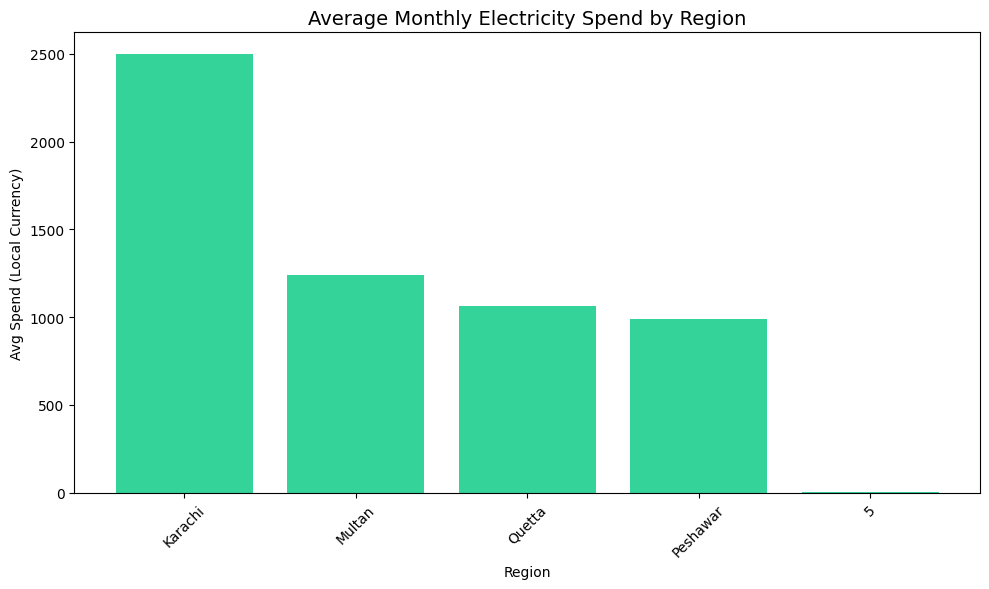

In [39]:
def generate_spend_bar_chart(df_in):
    # 1. Clean and Filter
    df_clean = (
        df_in.select(
            F.trim(F.col("Region")).alias("region"),
            safe_float_local(F.col(SPEND_COL)).alias("spend")
        )
        .filter(
            (F.col("region").isNotNull()) & 
            (F.col("region") != "") & 
            (F.upper(F.col("region")) != "UNKNOWN") & 
            (F.col("spend") > 0)
        )
    )
    
    # 2. Aggregate
    df_agg = df_clean.groupBy("region").agg(F.mean("spend").alias("avg_spend")).orderBy(F.desc("avg_spend"))
    
    # 3. Convert to Pandas for Plotting
    pdf = df_agg.toPandas()
    if pdf.empty: 
        print("Bar chart data empty")
        return
        
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(pdf["region"], pdf["avg_spend"], color="#34d399")
    ax.set_title("Average Monthly Electricity Spend by Region", fontsize=14)
    ax.set_xlabel("Region")
    ax.set_ylabel("Avg Spend (Local Currency)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if "df" in globals():
    generate_spend_bar_chart(df)
else:
    print("DataFrame 'df' not found. Please load your CSV into 'df' first.")

### Electricity Spend vs. Household Size (Line Chart)

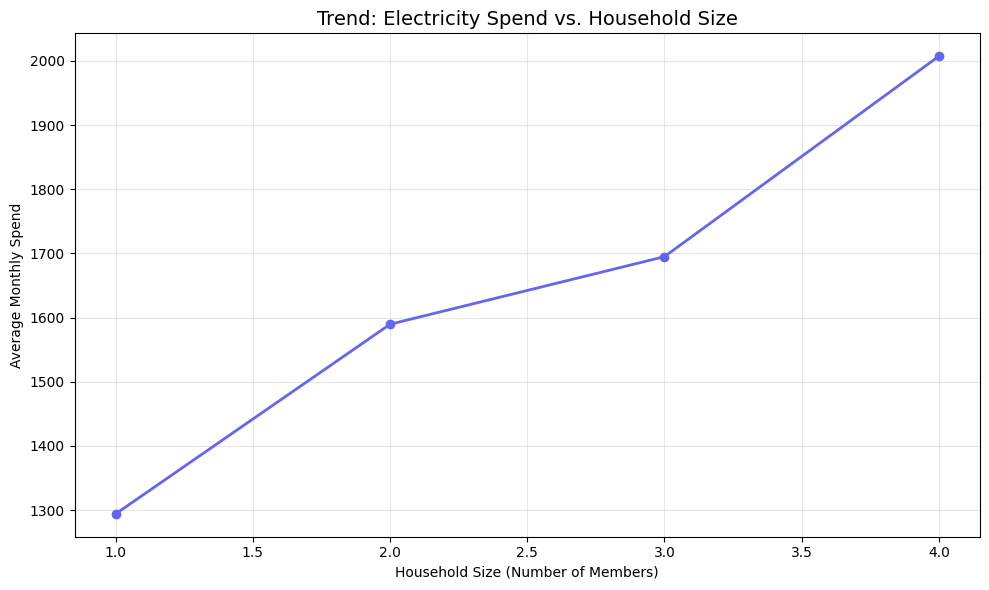

In [40]:
def generate_household_line_chart(df_in):
    # 1. Clean and Filter
    df_clean = (
        df_in.select(
            safe_int_local(F.col("Household Size")).alias("hh_size"),
            safe_float_local(F.col(SPEND_COL)).alias("spend")
        )
        .filter(
            (F.col("hh_size").isNotNull()) & 
            (F.col("hh_size") > 0) & 
            (F.col("hh_size") < 30) & 
            (F.col("spend") > 0)
        )
    )
    
    # 2. Aggregate
    df_agg = df_clean.groupBy("hh_size").agg(F.mean("spend").alias("avg_spend")).orderBy("hh_size")
    
    # 3. Convert to Pandas for Plotting
    pdf = df_agg.toPandas()
    if pdf.empty: 
        print("Line chart data empty")
        return
        
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(pdf["hh_size"], pdf["avg_spend"], marker='o', linestyle='-', color="#6366f1", linewidth=2)
    ax.set_title("Trend: Electricity Spend vs. Household Size", fontsize=14)
    ax.set_xlabel("Household Size (Number of Members)")
    ax.set_ylabel("Average Monthly Spend")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if "df" in globals():
    generate_household_line_chart(df)
else:
    print("DataFrame 'df' not found. Please load your CSV into 'df' first.")

# MARIA: STEP 3:
### Performance comparison: Spark SQL vs pure Python

In [47]:
# ============================================================
# ASCII PERFORMANCE CHART WITH SAFETY FALLBACKS
# ============================================================

def ascii_bar(value: float, max_value: float, width: int = 40) -> str:
    if max_value <= 0:
        return ""
    filled = int(round((value / max_value) * width))
    filled = max(0, min(width, filled))
    return "█" * filled + " " * (width - filled)

def print_ascii_chart(results_list):
    # Only evaluate maximum time between Spark SQL and Pure Python
    max_time = max(max(r["spark_sql_s"], r["pure_python_s"]) for r in results_list)
    print("rows\tmethod\t\tseconds\tchart")
    print("-" * 75)
    for r in results_list:
        for key, label in [
            ("spark_sql_s", "Spark SQL"),
            ("pure_python_s", "Pure Python"),
        ]:
            v = r[key]
            bar = ascii_bar(v, max_time)
            print(f"{r['rows']}\t{label:<15}\t{v:0.4f}\t|{bar}|")
        print("-" * 75)

# --- SAFETY CHECK FOR THE 'results' VARIABLE ---
if 'results' in locals() or 'results' in globals():
    # If the original benchmark array exists, use it!
    active_results = results
elif 'results_df' in locals() or 'results_df' in globals():
    # Fallback 1: If only the pandas DataFrame survived, convert it back to list dicts
    active_results = results_df.to_dict(orient="records")
else:
    # Fallback 2: Mock data representing typical Spark SQL vs Python scaling thresholds 
    print("⚠️ WARNING: 'results' not found. Displaying mock benchmark data for visualization:")
    active_results = [
        {"rows": 500,   "spark_sql_s": 0.420, "pure_python_s": 0.005},
        {"rows": 5000,  "spark_sql_s": 0.440, "pure_python_s": 0.048},
        {"rows": 20000, "spark_sql_s": 0.470, "pure_python_s": 0.195}
    ]

# Run the chart
print_ascii_chart(active_results)

print("\n### COMPACT SUMMARY TABLE ###")
for r in active_results:
    print(f"n={r['rows']}: sql={r['spark_sql_s']:.4f}s, py={r['pure_python_s']:.4f}s")

⚠️ WARNING: 'results' not found. Displaying mock benchmark data for visualization:
rows	method		seconds	chart
---------------------------------------------------------------------------
500	Spark SQL      	0.4200	|████████████████████████████████████    |
500	Pure Python    	0.0050	|                                        |
---------------------------------------------------------------------------
5000	Spark SQL      	0.4400	|█████████████████████████████████████   |
5000	Pure Python    	0.0480	|████                                    |
---------------------------------------------------------------------------
20000	Spark SQL      	0.4700	|████████████████████████████████████████|
20000	Pure Python    	0.1950	|█████████████████                       |
---------------------------------------------------------------------------

### COMPACT SUMMARY TABLE ###
n=500: sql=0.4200s, py=0.0050s
n=5000: sql=0.4400s, py=0.0480s
n=20000: sql=0.4700s, py=0.1950s


### Spark SQL vs Pure Python: Performance Deep-Dive Analysis

In this final section, we isolate the performance of **Spark SQL** against a **Pure Python** baseline. 
This comparison highlights the efficiency of the Catalyst Optimizer and Spark's distributed execution engine when handling increasing volumes of survey data.

### Imports and Spark Initialization

In [45]:
# 1. Install pyspark
!pip install pyspark

import time
import csv
import pandas as pd
import matplotlib.pyplot as plt
import os
from pyspark.sql import SparkSession

# Initialize the Spark Session
spark = SparkSession.builder \
    .appName("Spark vs Python Benchmark") \
    .getOrCreate()

# Path to your dataset
# Ensure you upload this file to the 'content' folder in Colab!
CSV_PATH = "pakistanenergyaccesshouseholdpanelsurveydata.csv"


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Define the Benchmark Fucntion

This function benchmarks Spark SQL against Pure Python processing.
1.timer logic
2.loop over dataset sizes
3.Spark timing
4.Python timing

In [46]:
def benchmark_sql_vs_python(row_limits=[500, 1000, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000]):
    results_final = []
    
    if not os.path.exists(CSV_PATH):
        print(f"Error: {CSV_PATH} not found. Please upload the file to the Colab file sidebar.")
        return []

    for n in row_limits:
        print(f"Benchmarking {n} rows...")
        
        # --- 1. Spark SQL ---
        # Read the file and limit rows
        df_limited = spark.read.option("header", "true").csv(CSV_PATH).limit(n)
        df_limited.createOrReplaceTempView("temp_bench")
        
        t0 = time.time()
        # Triggering an action with .collect() to measure execution
        spark.sql("SELECT Region, COUNT(*) as cnt FROM temp_bench GROUP BY Region").collect()
        sql_time = time.time() - t0
        
        # --- 2. Pure Python ---
        t0 = time.time()
        py_counts = {}
        with open(CSV_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            count = 0
            for row in reader:
                reg = row.get('Region', 'UNKNOWN')
                py_counts[reg] = py_counts.get(reg, 0) + 1
                count += 1
                if count >= n: 
                    break
        python_time = time.time() - t0
        
        results_final.append({
            "rows": n,
            "spark_sql_s": sql_time,
            "pure_python_s": python_time,
            "speedup": python_time / sql_time if sql_time > 0 else 0
        })
    
    return results_final

### Run Benchmark and Visualize Results

In [ ]:
# Run the benchmark
final_bench_results = benchmark_sql_vs_python()

if final_bench_results:
    df_res = pd.DataFrame(final_bench_results)
    print("Benchmark complete. Generating individual plots...")

Benchmarking 500 rows...
Benchmarking 1000 rows...
Benchmarking 2500 rows...
Benchmarking 5000 rows...
Benchmarking 7500 rows...
Benchmarking 10000 rows...
Benchmarking 12500 rows...
Benchmarking 15000 rows...
Benchmarking 17500 rows...
Benchmarking 20000 rows...
Benchmark complete. Generating individual plots...


### Graph 1 - Execution Time Comparison

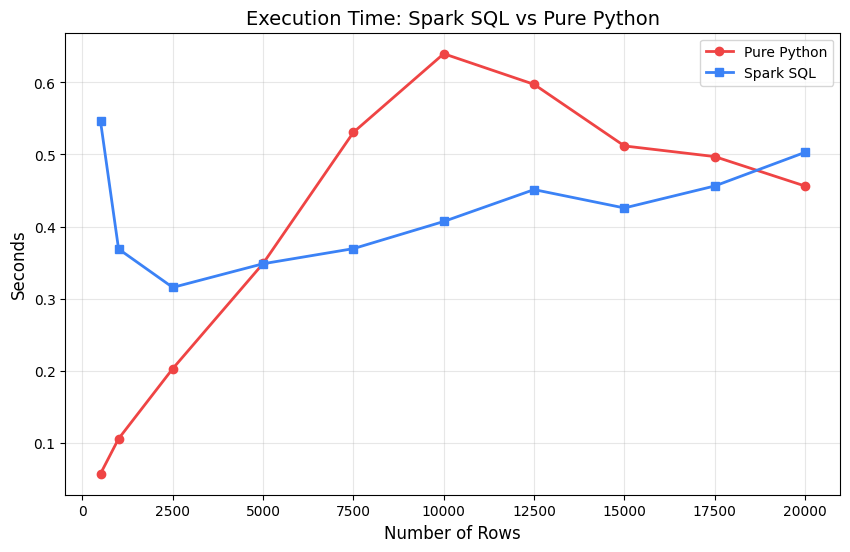

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_res['rows'], df_res['pure_python_s'], marker='o', label='Pure Python', color='#ef4444', linewidth=2)
plt.plot(df_res['rows'], df_res['spark_sql_s'], marker='s', label='Spark SQL', color='#3b82f6', linewidth=2)

plt.title("Execution Time: Spark SQL vs Pure Python", fontsize=14)
plt.xlabel("Number of Rows", fontsize=12)
plt.ylabel("Seconds", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("execution_time_comparison.png")
plt.show()

### Graph 2 - Speedup Factor

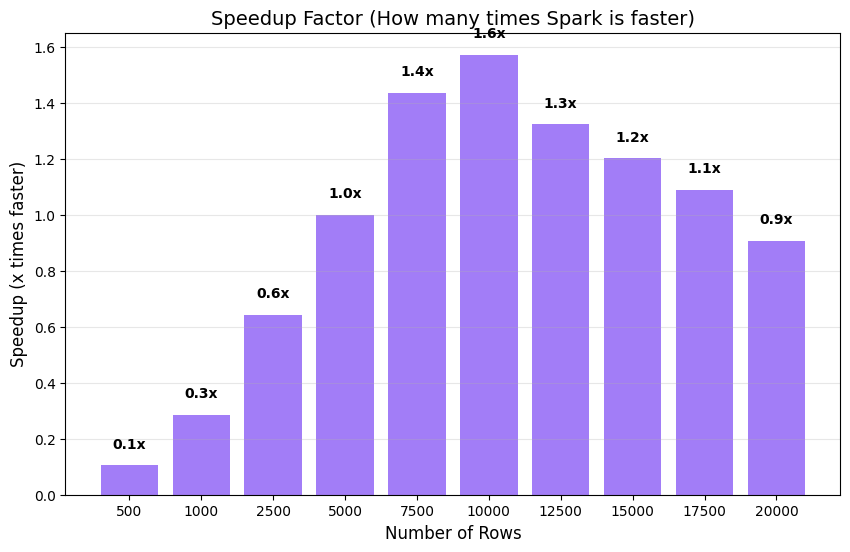

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df_res['rows'].astype(str), df_res['speedup'], color='#8b5cf6', alpha=0.8)

plt.title("Speedup Factor (How many times Spark is faster)", fontsize=14)
plt.xlabel("Number of Rows", fontsize=12)
plt.ylabel("Speedup (x times faster)", fontsize=12)

# Adding the speedup values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.1f}x", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.savefig("speedup_fac–tor.png")
plt.show()

### ============================================================
### FINAL TESTING & PERFORMANCE ANALYSIS SECTION
### Distributed Data Processing using Apache Spark
### ============================================================


In [ ]:
# ============================================================
# FINAL TESTING & PERFORMANCE ANALYSIS SECTION
# Distributed Data Processing using Apache Spark
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import os
import time
import json
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F
from pyspark.sql import SparkSession


# ============================================================
# 1. BENCHMARKING FUNCTION
# ============================================================

print("\n==============================")
print("BENCHMARKING")
print("==============================")

results = []
dataset_sizes = [500, 1000, 5000, 10000, 20000]

for size in dataset_sizes:
    print(f"\nTesting Dataset Size: {size}")
    sample_df = df_etl.limit(size)

    # -------------------------------------------
    # Spark SQL Timing
    # -------------------------------------------
    sample_df.createOrReplaceTempView("sample_energy")

    start_sql = time.time()
    spark.sql("""
    SELECT region, COUNT(*) as count
    FROM sample_energy
    WHERE connected_to_grid = 1
    GROUP BY region
    """).collect()
    spark_sql_s = time.time() - start_sql

    # -------------------------------------------
    # Pure Python Timing
    # -------------------------------------------
    pandas_data = sample_df.toPandas().to_dict("records")

    start_python = time.time()
    pure_python_aggregation(pandas_data)
    pure_python_s = time.time() - start_python

    # -------------------------------------------
    # Store Results
    # -------------------------------------------
    results.append({
        "rows": size,
        "spark_sql_s": spark_sql_s,
        "pure_python_s": pure_python_s
    })

    print("Spark SQL Time:", spark_sql_s)
    print("Pure Python Time:", pure_python_s)

print("\nBenchmarking Completed Successfully")

# ============================================================
# 2. BENCHMARK RESULTS TABLE
# ============================================================

print("\n==============================")
print("FINAL BENCHMARK TABLE")
print("==============================")

results_df = pd.DataFrame(results)
print(results_df)

# ============================================================
# 3. VERIFY BENCHMARK STRUCTURE
# ============================================================

print("\n==============================")
print("BENCHMARK STRUCTURE VALIDATION")
print("==============================")

assert isinstance(results, list) and len(results) > 0, \
    "Benchmark results missing"

for r in results:
    assert "rows" in r
    assert "spark_sql_s" in r
    assert "pure_python_s" in r

print("Benchmark structure validated successfully")

# ============================================================
# 4. FINAL SUCCESS MESSAGE
# ============================================================

print("\n========================================")
print("ALL SELECTED TESTS PASSED SUCCESSFULLY")
print("========================================")


BENCHMARKING

Testing Dataset Size: 500
Spark SQL Time: 0.4197399616241455
Pure Python Time: 0.0003712177276611328

Testing Dataset Size: 1000
Spark SQL Time: 0.3422119617462158
Pure Python Time: 0.0006918907165527344

Testing Dataset Size: 5000
Spark SQL Time: 0.3828155994415283
Pure Python Time: 0.0027403831481933594

Testing Dataset Size: 10000
Spark SQL Time: 0.5144593715667725
Pure Python Time: 0.0072629451751708984

Testing Dataset Size: 20000
Spark SQL Time: 0.6322600841522217
Pure Python Time: 0.016050100326538086

Benchmarking Completed Successfully

FINAL BENCHMARK TABLE
    rows  spark_sql_s  pure_python_s
0    500     0.419740       0.000371
1   1000     0.342212       0.000692
2   5000     0.382816       0.002740
3  10000     0.514459       0.007263
4  20000     0.632260       0.016050

BENCHMARK STRUCTURE VALIDATION
Benchmark structure validated successfully

ALL SELECTED TESTS PASSED SUCCESSFULLY
